In [3]:
import pickle
import pandas as pd
with open('../pickles/music_stats.pickle', 'rb') as f:
    df_stats: pd.DataFrame = pickle.load(f)

print(df_stats.columns)
df_stats['all_nodes_nodes'].describe()

Index(['comp_id', 'type_count', 'track_nodes', 'track_clusters',
       'track_dupe_count', 'all_nodes_nodes', 'artist_nodes',
       'artist_clusters', 'artist_dupe_count', 'area_nodes', 'area_clusters',
       'area_dupe_count'],
      dtype='str')


count    2894.000000
mean       12.696268
std       184.118460
min         2.000000
25%         2.000000
50%         3.000000
75%         4.000000
max      4934.000000
Name: all_nodes_nodes, dtype: float64

/var/folders/05/m7p6wsw10_qfvbrgqsl0m2p40000gn/T/ipykernel_31111/307758534.py:7: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = False


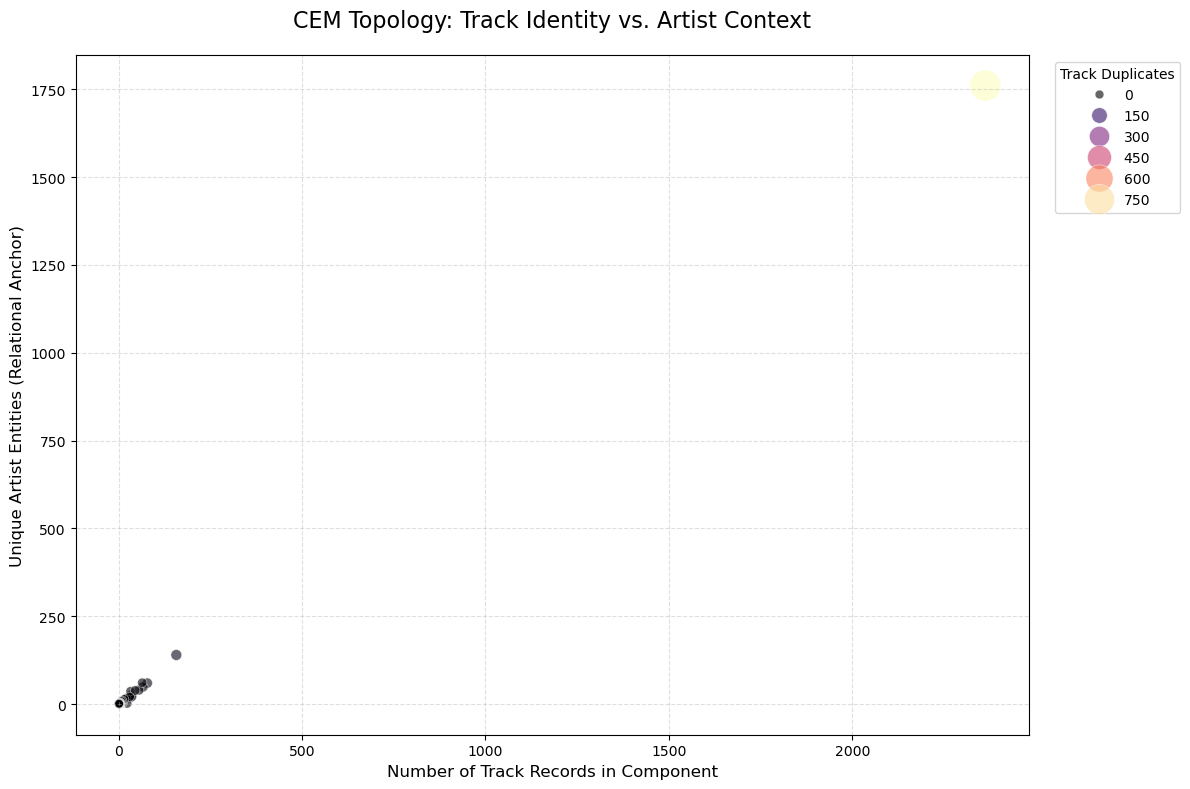

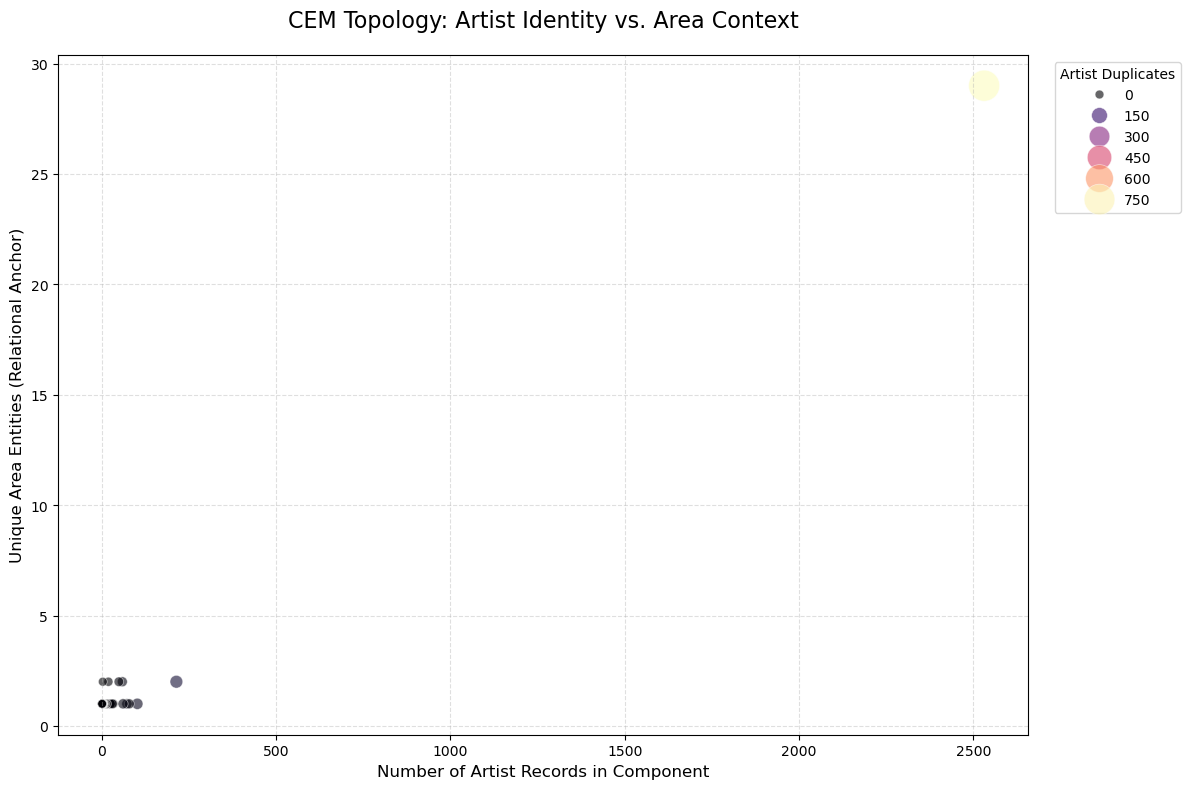

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fix for the Pandas Copy-on-Write NameError
try:
    pd.options.mode.copy_on_write = False
except Exception:
    pass

def plot_cem_topology(df_stats, primary="track", context="artist"):
    """
    Visualizes the CEM topology for Music Datasets.
    
    Args:
        df_stats: The DataFrame with 'track', 'artist', 'area' columns.
        primary: The entity we are deduplicating (e.g., 'track').
        context: The entity providing relational evidence (e.g., 'artist').
    """
    # 1. Deduplicate the component rows (removes the triple-appended rows)
    df_clean = df_stats.drop_duplicates(subset=['comp_id']).copy()
    
    # 2. Dynamically identify the columns based on your schema
    x_col = f"{primary}_nodes"          # Identity Complexity
    y_col = f"{context}_clusters"       # Relational Signal
    size_col = f"{primary}_dupe_count"  # Number of duplicates
    
    # 3. Create the Visualization
    plt.figure(figsize=(12, 8))
    
    # Use a scatter plot where:
    # - X is the number of records of the primary entity
    # - Y is the number of unique related entities providing context
    # - Size and Color represent the duplicate count intensity
    sns.scatterplot(
        data=df_clean,
        x=x_col,
        y=y_col,
        size=size_col,
        hue=size_col,
        palette="magma",
        sizes=(40, 500),
        alpha=0.6,
        edgecolor="w",
        linewidth=0.5
    )
    
    # 4. Professional Formatting for Advisor Presentation
    plt.title(f"CEM Topology: {primary.capitalize()} Identity vs. {context.capitalize()} Context", 
              fontsize=16, pad=20)
    plt.xlabel(f"Number of {primary.capitalize()} Records in Component", fontsize=12)
    plt.ylabel(f"Unique {context.capitalize()} Entities (Relational Anchor)", fontsize=12)
    
    # Move legend outside for readability
    plt.legend(title=f"{primary.capitalize()} Duplicates", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

# Example Usage:
plot_cem_topology(df_stats, primary="track", context="artist")
plot_cem_topology(df_stats, primary="artist", context="area")

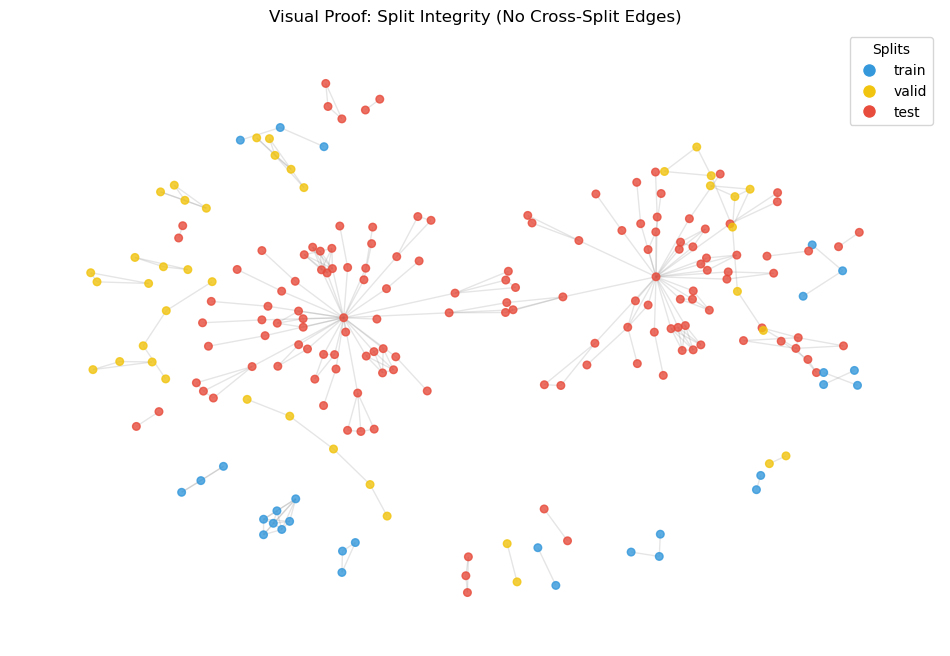

In [11]:
import networkx as nx
import matplotlib.pyplot as plt
import random

def visualize_split_integrity(splits, global_rel_map, num_comps_to_show=30):
    """
    Plots a sample of components color-coded by split.
    If leakage-free, no edges will connect different colored clusters.
    """
    G = nx.Graph()
    # 1. Map component to its split color
    split_names = ["train", "valid", "test"]
    colors = {"train": "#3498db", "valid": "#f1c40f", "test": "#e74c3c"}
    
    node_colors = {}
    sampled_nodes = set()
    
    # 2. Select a subset of components to visualize
    for name, components in zip(split_names, splits):
        sampled_comps = random.sample(components, min(len(components), num_comps_to_show // 3))
        for comp in sampled_comps:
            for node_id in comp["all_nodes"]:
                node_colors[node_id] = colors[name]
                sampled_nodes.add(node_id)

    # 3. Add only edges where both nodes are in our sample
    for u, neighbors in global_rel_map.items():
        u_id = u[0]
        if u_id in sampled_nodes:
            for v_id, v_type in neighbors:
                if v_id in sampled_nodes:
                    G.add_edge(u_id, v_id)

    # 4. Plot
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.15, seed=42)
    
    # Draw nodes
    colors_list = [node_colors[node] for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_size=30, node_color=colors_list, alpha=0.8)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color="gray")
    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=k,
                              markerfacecolor=v, markersize=10) for k, v in colors.items()]
    plt.legend(handles=legend_elements, loc='upper right', title="Splits")
    
    plt.title("Visual Proof: Split Integrity (No Cross-Split Edges)")
    plt.axis('off')
    plt.show()

with open('../pickles/music_splits.pickle', 'rb') as f:
    splits: pd.DataFrame = pickle.load(f)

with open('../pickles/music_relmap.pickle', 'rb') as f:
    global_rel_map: pd.DataFrame = pickle.load(f)

visualize_split_integrity(splits, global_rel_map)

In [5]:
import pandas as pd
from rapidfuzz import fuzz

tracks = pd.read_csv("../data/raw/music/10/track.csv")
tracks.set_index('track', inplace=True)
tracks_dups = pd.read_csv("../data/raw/music/10/track_dups.csv")

def calculate_record_similarity(row, records_df):
    """
    Computes a weighted similarity between two records.
    """
    r1 = records_df.loc[row['1']]
    r2 = records_df.loc[row['2']]
    
    # Calculate similarity for specific attributes
    # Using token_set_ratio is often better for ER (handles word reordering)
    title_sim = fuzz.token_set_ratio(r1['name'], r2['name']) / 100.0
    
    # Simple binary match for year
    year_sim = 1.0 if r1['length'] == r2['length'] else 0.0
    
    # Weighted average (Adjust weights based on your schema)
    return (title_sim * 0.8) + (year_sim * 0.2)

# 2. Compute similarity for all labeled duplicates
tracks_dups['similarity_score'] = tracks_dups.apply(
    calculate_record_similarity, 
    axis=1, 
    records_df=tracks
)

# 3. Sort ascending to find "Hard Matches" 
# (Items labeled as duplicate but with low string similarity)
hard_matches = tracks_dups.sort_values(by='similarity_score', ascending=True)

print("--- Hardest Matches (Low Similarity, but are Duplicates) ---")
for _, row in hard_matches.head(10).iterrows():
    r1 = tracks.loc[row['1']]
    r2 = tracks.loc[row['2']]
    print(f"Score: {row['similarity_score']:.2f}")
    print(f"  R1: {r1['name']} ({r1['length']})")
    print(f"  R2: {r2['name']} ({r2['length']})\n")

--- Hardest Matches (Low Similarity, but are Duplicates) ---
Score: 0.47
  R1: Shr (177000.0)
  R2: Sbe (177000.0)

Score: 0.60
  R1: Dunkiahk (nan)
  R2: Dunckirk (nan)

Score: 0.60
  R1: Amna (317640.0)
  R2: Annz (317640.0)

Score: 0.64
  R1: Dunkiahk (nan)
  R2: Dunkirk (nan)

Score: 0.67
  R1: Mooiste 0gen (290000.0)
  R2: Mooistr ogen (290000.0)

Score: 0.68
  R1: Worts (355840.0)
  R2: Wordd (355840.0)

Score: 0.69
  R1: Modern Myjtery (nan)
  R2: Modern Mvstery (nan)

Score: 0.69
  R1: Seagreen Seremades (208160.0)
  R2: Sesgreen Serenades (208160.0)

Score: 0.70
  R1: Blood Is Tin (nan)
  R2: Blood Is Th9n (nan)

Score: 0.72
  R1: Ten Seconcl News (nan)
  R2: Ten Seconf News (nan)



In [6]:
import random

def find_hard_non_matches(records_df, duplicates_df, sample_size=1000):
    """
    Finds non-duplicate pairs with high similarity (Hard Non-Matches).
    """
    # 1. Create a set of known duplicates for fast lookup (ground truth)
    # We store both (A, B) and (B, A) to ensure we don't pick them as non-matches
    known_dups = set()
    for _, row in tracks_dups.iterrows():
        known_dups.add((row['1'], row['2']))
        known_dups.add((row['2'], row['1']))

    # 2. Blocking: Group by 'year' to find plausible non-match candidates
    # This prevents us from comparing "The Karate Kid" to "Finding Nemo"
    candidates = []
    grouped = tracks.groupby('length')

    for year, group in grouped:
        if len(group) < 2:
            continue
            
        # Get IDs in this year block
        ids = group.index.tolist()
        
        # Sample pairs within the same year to find "Hard Non-Matches"
        # Increase 'k' if you want a more exhaustive search
        for _ in range(min(len(ids) * 2, 500)): 
            idx1, idx2 = random.sample(ids, 2)
            
            # Only proceed if they are NOT known duplicates
            if (idx1, idx2) not in known_dups:
                candidates.append((idx1, idx2))

    # 3. Calculate similarity for these candidates
    results = []
    for left_id, right_id in candidates[:sample_size]:
        r1 = tracks.loc[left_id]
        r2 = tracks.loc[right_id]
        
        # Scoring logic
        title_sim = fuzz.token_set_ratio(str(r1['name']), str(r2['name'])) / 100.0
        
        results.append({
            'left_id': left_id,
            'right_id': right_id,
            'similarity_score': title_sim,
            'left_title': r1['name'],
            'right_title': r2['name'],
            'year': r1['length']
        })

    # 4. Sort descending: High similarity + Not Duplicates = Hard Non-Matches
    hard_non_matches = pd.DataFrame(results).sort_values(by='similarity_score', ascending=False)
    
    return hard_non_matches

# Run the detection
hard_non_matches = find_hard_non_matches(tracks, tracks_dups)

print("--- Top 10 Hard Non-Matches (High Similarity, but NOT Duplicates) ---")
print(hard_non_matches[['left_title', 'right_title', 'similarity_score']].head(10))

--- Top 10 Hard Non-Matches (High Similarity, but NOT Duplicates) ---
                                          left_title  \
21                                           silence   
603  My Best Friends Wedding Do You Really Love Film   
2                                            silence   
3                                            silence   
4                                            silence   
20                                           silence   
24                                           silence   
10                                           silence   
23                                           silence   
608                                             Film   

                                         right_title  similarity_score  
21                                           silence               1.0  
603                                             Film               1.0  
2                                            silence               1.0  
3                    

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def evaluate_difficulty(movies_df, junction_df, duplicates_df, top_k=10):
    # 1. Prepare "Flattened" Record Strings for TF-IDF
    # Combine title and any other text features into one string
    movies_df['combined_text'] = movies_df['primaryTitle'].astype(str) + " " + movies_df.get('genres', '')
    
    tfidf = TfidfVectorizer(stop_words='english', analyzer='char_wb', ngram_range=(3,3))
    tfidf_matrix = tfidf.fit_transform(movies_df['combined_text'])
    
    # 2. Map Neighborhoods (Junction Table: movie_id -> [actor_ids])
    # Assuming junction_df has columns ['movie_id', 'neighbor_id']
    neighborhoods = junction_df.groupby('tconst')['nconst'].apply(set).to_dict()

    # 3. Create Ground Truth Set
    known_dups = set()
    for _, row in duplicates_df.iterrows():
        # Store as sorted tuple to handle (A,B) and (B,A) identically
        pair = tuple(sorted((row['1'], row['2'])))
        known_dups.add(pair)

    results = []
    movie_ids = movies_df.index.tolist()

    # 4. For a sample of movies, find the most similar others
    for i, m1_id in enumerate(movie_ids):
        # Get cosine similarity of this movie against ALL others
        sim_vector = cosine_similarity(tfidf_matrix[i], tfidf_matrix).flatten()
        
        # Get indices of top_k most similar (excluding itself)
        related_indices = sim_vector.argsort()[-(top_k+1):-1][::-1]
        
        for idx in related_indices:
            m2_id = movie_ids[idx]
            
            # --- THE CRITICAL CHECKS ---
            # 1. Identity Check: Skip if it's the same record
            if m1_id == m2_id:
                continue
            
            # 2. Symmetry Check: To avoid (A,B) and (B,A) duplicates in our results,
            # we only process if ID1 < ID2 (lexicographical order)
            if str(m1_id) >= str(m2_id):
                continue
            
            score = sim_vector[idx]
            
            # Neighborhood Jaccard Similarity
            n1 = neighborhoods.get(m1_id, set())
            n2 = neighborhoods.get(m2_id, set())
            
            intersection = len(n1.intersection(n2))
            union = len(n1.union(n2))
            jaccard = intersection / union if union > 0 else 0
            
            is_dup = (m1_id, m2_id) in known_dups or (m2_id, m1_id) in known_dups
            
            results.append({
                'id1': m1_id, 'id2': m2_id,
                'string_sim': score,
                'neighbor_sim': jaccard,
                'is_duplicate': is_dup
            })

    return pd.DataFrame(results)

# Run Analysis
diff_df = evaluate_difficulty(tracks, acts_in, movie_dups)

# --- FINDING THE HARD CASES ---

# 1. Hard Matches (Duplicates with low similarity)
hard_matches = diff_df[diff_df['is_duplicate']].sort_values(['string_sim', 'neighbor_sim']).head(30)
display(hard_matches)

# 2. Hard Non-Matches (High similarity, but NOT duplicates)
hard_non_matches = diff_df[~diff_df['is_duplicate']].sort_values('string_sim', ascending=False).head(10)
display(hard_non_matches)

# 3. Neighborhood Conflict (Looks similar, but neighbors are totally different)
neighborhood_conflict = diff_df[(diff_df['string_sim'] > 0.4) & (diff_df['string_sim'] < 0.99)& (diff_df['neighbor_sim'] == 0)].sort_values('string_sim', ascending=False).head(10)
display(neighborhood_conflict)

NameError: name 'acts_in' is not defined

In [ ]:
my_list = [{"name": "abc", "age": 10}, {"name": "def", "age": 40}]

names = {
    "name": name
    for entry in my_list
}

indexed_dfs = {
                    rel: processed_entities[rel_name].df.set_index(CONFIGS[rel_name].id_col)
                    for name in rel.items() for rel in cfg.rels
                }


{'name': 'abc', 'age': 10}
{'name': 'def', 'age': 40}
